In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
def gaussian(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.exp(
        -(x**2) / 2
    )


def boxcar(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        torch.abs(x) < 1.0
    ).to(dtype=torch.float32)


def constant(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.ones_like(x)


def epanechikov(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.maximum(
        1 - torch.abs(x),
        torch.zeros_like(x),
    )


def target_function(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        2 * torch.sin(x)
        + x
    )



kernels = (
    gaussian,
    boxcar,
    constant,
    epanechikov,
)

kernel_names = (
    "Gaussian",
    "Boxcar",
    "Constant",
    "Epanechikov",
)


num_train = 40


# Key:
x_train, _ = torch.sort(
    torch.rand(num_train) * 5
)

# Value:
y_train = (
    target_function(x_train)
    + torch.randn(num_train)
)


# Query: prediction을 구할 위치
x_val = torch.arange(
    0,
    5,
    0.1,
)

y_val = target_function(
    x_val
)


print(
    "Number of Keys:",
    x_train.numel(),
)
print(
    "Number of Queries:",
    x_val.numel(),
)

# Keys    : x_train [40]
# Values  : y_train [40]
# Queries : x_val   [50]

Number of Keys: 40
Number of Queries: 50


In [3]:
# Nadaraya-Watson Attention Pooling

def nadaraya_watson(
    x_train: torch.Tensor, # Key  
    y_train: torch.Tensor, # Value 
    queries: torch.Tensor, # Query
    kernel,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    
    # Distances k ~ q:
    # Key:[K, 1] - Query:[1, Q] -> [K, Q]
    distances = (
        x_train.reshape(-1, 1)   # x_train: [K, 1]
        - queries.reshape(1, -1) # queries: [1, Q]
    )
    
    # Transformation: distances -> similarities
    similarities = kernel(
        distances
    ).to(dtype=torch.float32)
    
    # Attention Weights / Normalization to each Query:
    # [K, Q] / [1, Q] -> [K, Q]
    attention_weights = (
        similarities
        / similarities.sum(
            dim=0,
            keepdim=True,
        )
    )
    
    # 각 Query에 대해 Prediction:
    # Value:[K] @ Weight:[K, Q] -> [Q]
    predictions = (
        y_train @ attention_weights
    )
    
    return (
        predictions,
        attention_weights,
    )

In [4]:
# Gaussian Kernel Width

from collections.abc import Callable


KernelFunction = Callable[
    [torch.Tensor],
    torch.Tensor,
]


# Gaussian Kernel Function with sigma
def gaussian_with_width(
    sigma: float,
) -> KernelFunction:
    
    def kernel(
        distances: torch.Tensor,
    ) -> torch.Tensor:
        return torch.exp(
            - (distances**2)
            / (2 * sigma**2)
        )
        
    return kernel



sigmas = (
    0.1,
    0.2,
    0.5,
    1.0,
)


width_names = tuple(
    f"Sigma {sigma}"
    for sigma in sigmas
)


width_kernels = tuple(
    gaussian_with_width(sigma)
    for sigma in sigmas
)

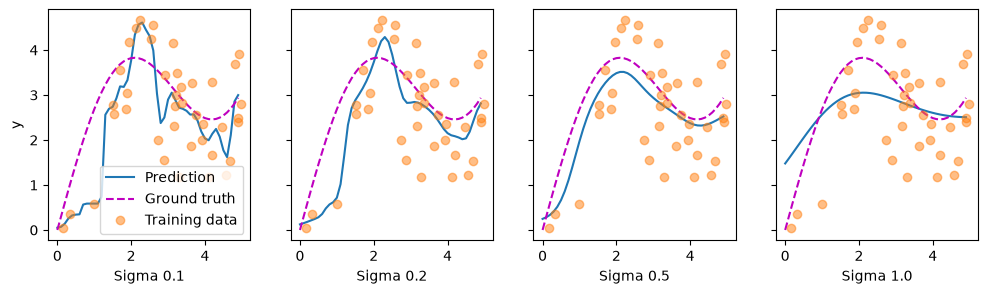

In [5]:
# Kernel Width별 Prediction

# sigma에 따라 Prediction의 smoothness가 어떻게 변하는지 비교


figure, axes = d2l.plt.subplots(
    1,
    4,
    sharey=True,
    figsize=(12, 3),
)


for kernel, name, axis in zip(
    width_kernels,
    width_names,
    axes,
    strict=True,
):
    predictions, _ = nadaraya_watson(
        x_train=x_train,
        y_train=y_train,
        queries=x_val,
        kernel=kernel,
    )

    axis.plot(
        x_val.detach().cpu().numpy(),
        predictions.detach().cpu().numpy(),
    )

    axis.plot(
        x_val.detach().cpu().numpy(),
        y_val.detach().cpu().numpy(),
        "m--",
    )

    axis.plot(
        x_train.detach().cpu().numpy(),
        y_train.detach().cpu().numpy(),
        "o",
        alpha=0.5,
    )

    axis.set_xlabel(
        name
    )


axes[0].set_ylabel(
    "y"
)

axes[0].legend([
    "Prediction",
    "Ground truth",
    "Training data",
])


d2l.plt.show()

# Graph 해석:
# Sigma 0.1: 가까운 Training Point에 강하게 반응해 Curve가 울퉁불퉁함
# Sigma 0.2: 여전히 local하지만 약간 smooth함
# Sigma 0.5: 더 넓은 주변 Data를 평균
# Sigma 1.0: 매우 smooth하지만 세부 변화가 약해짐

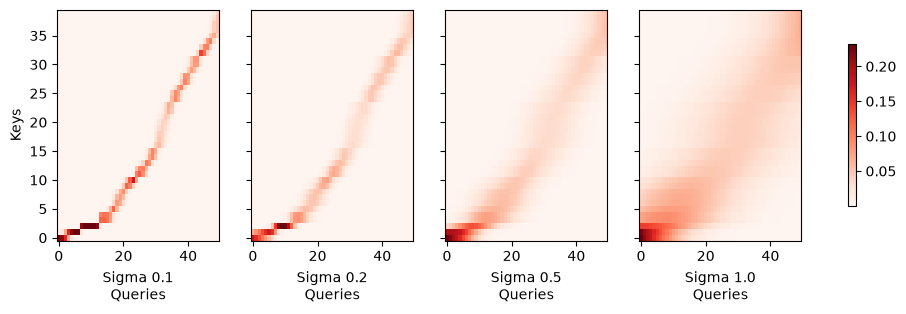

In [6]:
# Kernel Width별 Attention weight

# sigma가 Attention 범위를 어떻게 바꾸는 지 Heatmap으로 확인


figure, axes = d2l.plt.subplots(
    1,
    4,
    sharex=True,
    sharey=True,
    figsize=(12, 3),
)


last_image = None


for kernel, name, axis in zip(
    width_kernels,
    width_names,
    axes,
    strict=True,
):
    _, attention_weights = nadaraya_watson(
        x_train=x_train,
        y_train=y_train,
        queries=x_val,
        kernel=kernel,
    )

    last_image = axis.imshow(
        attention_weights.detach().cpu().numpy(),
        cmap="Reds",
        aspect="auto",
        origin="lower",
    )

    axis.set_xlabel(
        f"{name}\nQueries"
    )


axes[0].set_ylabel(
    "Keys"
)


if last_image is not None:
    figure.colorbar(
        last_image,
        ax=axes,
        shrink=0.7,
    )


d2l.plt.show()

# 작은 sigma
# → 좁고 진한 붉은 띠
# → 소수의 가까운 Key에 집중

# 큰 sigma
# → 넓게 퍼진 붉은 영역
# → 많은 Key에 Weight 분산``